# iMem — Semantic Image Search POC (Local / Embedded Qdrant)

Thin notebook that wires together the reusable `src` modules:
- `imem.encoder.ImageTextEncoder` — SigLIP2 image/text embedding
- `imem.vector_store.ImageVectorStore` — Qdrant storage/search (embedded mode here)
- `tools.dataloader` — Olivetti Faces + Caltech-101 test datasets
- `tools.visualize.show_results` — quick result grid

See `notebooks/02-poc.ipynb` for the equivalent flow against a Qdrant **server/container**.

Core logic is unit-tested in `tests/` (smoke tests for the encoder pipeline).


## Setup and Imports

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import torch
from PIL import Image
import matplotlib.pyplot as plt

from imem.encoder import ImageTextEncoder, get_device
from imem.vector_store import ImageVectorStore
from tools.dataloader import load_all_test_data
from tools.visualize import show_results

print(f'PyTorch version: {torch.__version__}')
print(f'MPS available: {torch.backends.mps.is_available()}')


PyTorch version: 2.12.1
MPS available: True


## Load Model

In [2]:
device = get_device()
print(f'Device: {device}')

encoder = ImageTextEncoder(device=device)
print(f'Model: {encoder.model_id}')
print(f'Embedding dim: {encoder.embedding_dim}')


Device: mps


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 408/408 [00:00<00:00, 6828.06it/s]


Model: google/siglip2-base-patch16-224
Embedding dim: 768


## Setup Qdrant

In [5]:
COLLECTION_NAME = 'images_siglip2_base'
#DB_PATH = '../qdrant_local'
host = "127.0.0.1"

store = ImageVectorStore(
    collection_name=COLLECTION_NAME,
    embedding_dim=encoder.embedding_dim,
    host=host,
)
print(f'Qdrant collection ready: {COLLECTION_NAME} ({store.count()} points)')


Qdrant collection ready: images_siglip2_base (0 points)


## Load Test Datasets

In [8]:
records = load_all_test_data()
image_paths = [str(r.path) for r in records]

print(f"Found {len(image_paths)} images ("
      f"{sum(1 for r in records if r.dataset == 'olivetti')} Olivetti, "
      f"{sum(1 for r in records if r.dataset == 'caltech101')} Caltech-101)")


Indexing Caltech-101 personal_images: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9144/9144 [00:00<00:00, 292095.44it/s]

Found 9544 images (400 Olivetti, 9144 Caltech-101)


## Index Images

In [10]:
from tqdm.auto import tqdm

INDEX_BATCH_SIZE = 128

new_image_paths = store.filter_new_paths(image_paths)
print(f"New images: {len(new_image_paths)}")

total_written = 0

if new_image_paths:
    with tqdm(
        total=len(new_image_paths),
        desc="Indexing images",
        unit="image",
    ) as pbar:
        for start in range(0, len(new_image_paths), INDEX_BATCH_SIZE):
            batch_paths = new_image_paths[start : start + INDEX_BATCH_SIZE]

            embeddings, valid_paths = encoder.encode_images(
                batch_paths,
                batch_size=INDEX_BATCH_SIZE,
                show_progress=False,
            )

            if len(valid_paths) > 0:
                n_written = store.upsert_images(
                    embeddings,
                    valid_paths,
                    show_progress=False,
                )

                total_written += n_written

            pbar.update(len(batch_paths))
            pbar.set_postfix(written=total_written)

    print(f"Indexed {total_written} images")
else:
    print("Nothing new to index.")

New images: 9288


Indexing images: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9288/9288 [08:12<00:00, 18.85image/s, written=9288]

Indexed 9288 images


## Text-to-Image Search

Query: a person's face with glasses
1. /Users/evpc/Documents/self_edu/imem/data/olivetti/person_01/sample_014.png (score: 0.1717)
2. /Users/evpc/Documents/self_edu/imem/data/olivetti/person_05/sample_050.png (score: 0.1716)
3. /Users/evpc/Documents/self_edu/imem/data/olivetti/person_01/sample_012.png (score: 0.1714)
4. /Users/evpc/Documents/self_edu/imem/data/olivetti/person_05/sample_055.png (score: 0.1710)
5. /Users/evpc/Documents/self_edu/imem/data/olivetti/person_30/sample_307.png (score: 0.1704)


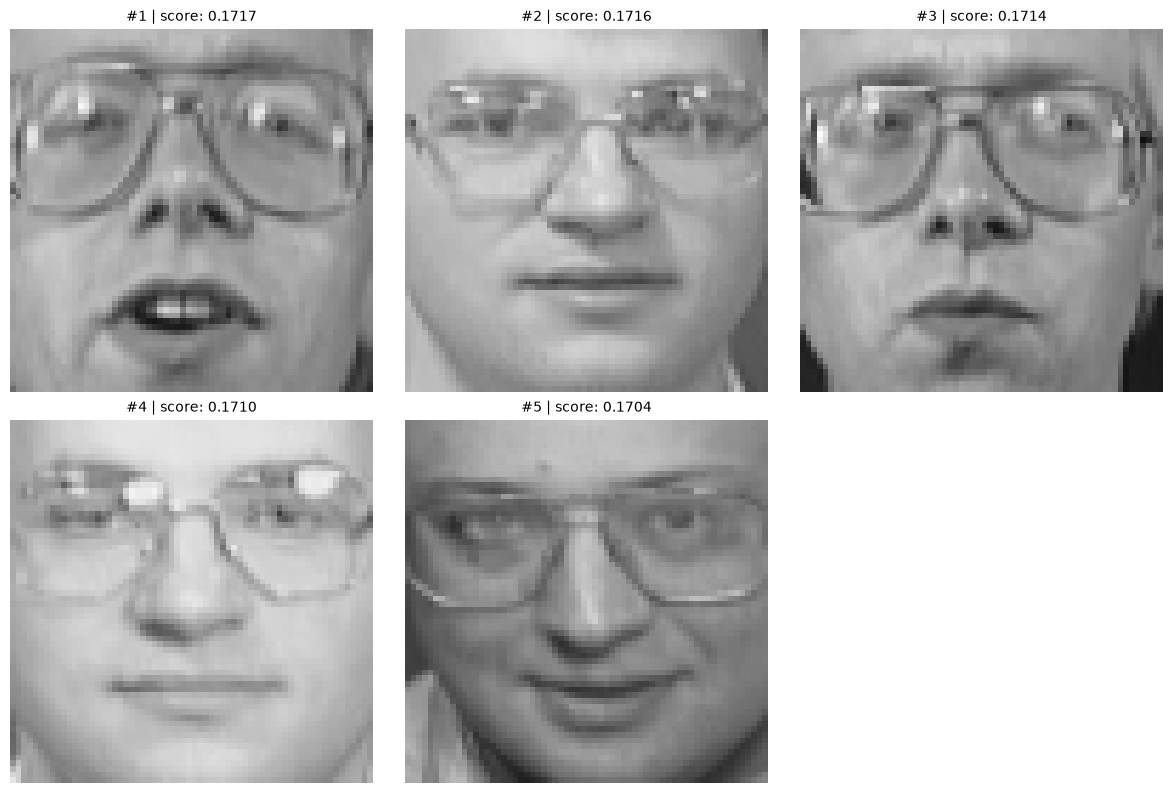

In [11]:
def search_by_text(query, top_k=5):
    query_emb = encoder.encode_text([query])[0]
    results = store.search(query_emb, top_k=top_k)
    print(f'Query: {query}')
    for rank, hit in enumerate(results.points, 1):
        print(f'{rank}. {hit.payload["path"]} (score: {hit.score:.4f})')
    return results


results = search_by_text("a person's face with glasses")
show_results(results, cols=3)


Query: an airplane
1. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/airplanes/image_0666.jpg (score: 0.1387)
2. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/airplanes/image_0789.jpg (score: 0.1379)
3. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/airplanes/image_0387.jpg (score: 0.1367)
4. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/airplanes/image_0610.jpg (score: 0.1357)
5. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/airplanes/image_0687.jpg (score: 0.1356)


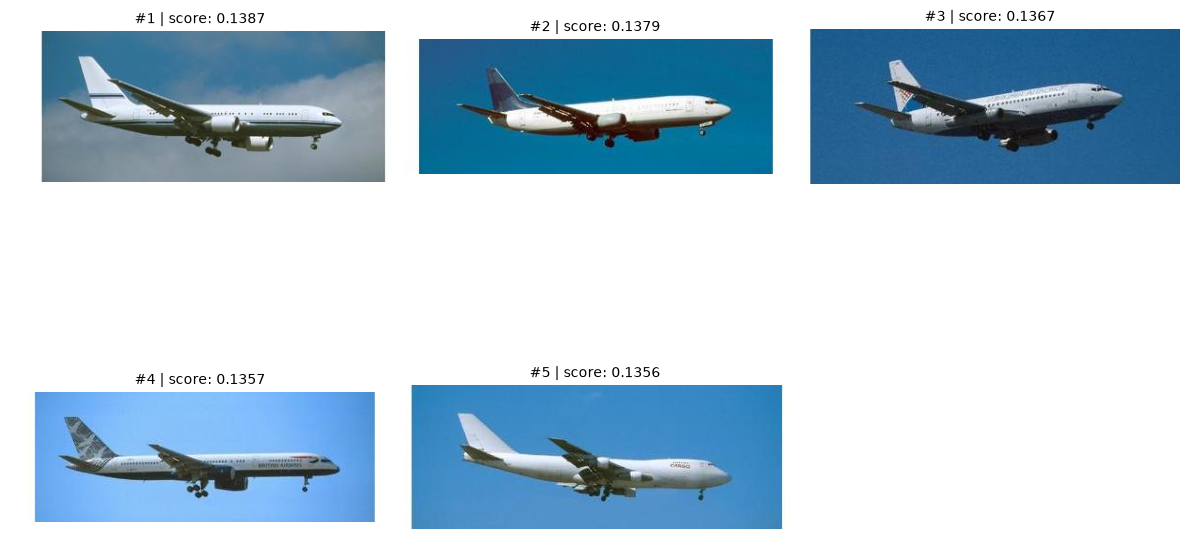

In [12]:
results = search_by_text("an airplane")
show_results(results, cols=3)


## Image-to-Image Search

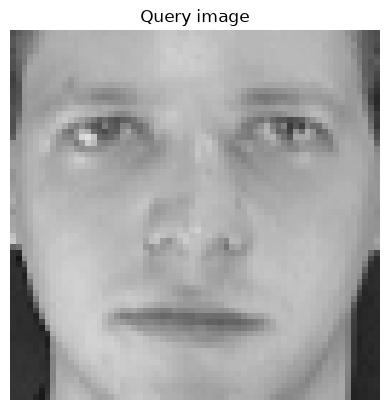

Query image: /Users/evpc/Documents/self_edu/imem/data/olivetti/person_00/sample_000.png
1. /Users/evpc/Documents/self_edu/imem/data/olivetti/person_00/sample_000.png (score: 1.0000)
2. /Users/evpc/Documents/self_edu/imem/data/olivetti/person_00/sample_002.png (score: 0.9812)
3. /Users/evpc/Documents/self_edu/imem/data/olivetti/person_23/sample_230.png (score: 0.9801)
4. /Users/evpc/Documents/self_edu/imem/data/olivetti/person_23/sample_236.png (score: 0.9796)
5. /Users/evpc/Documents/self_edu/imem/data/olivetti/person_17/sample_177.png (score: 0.9747)


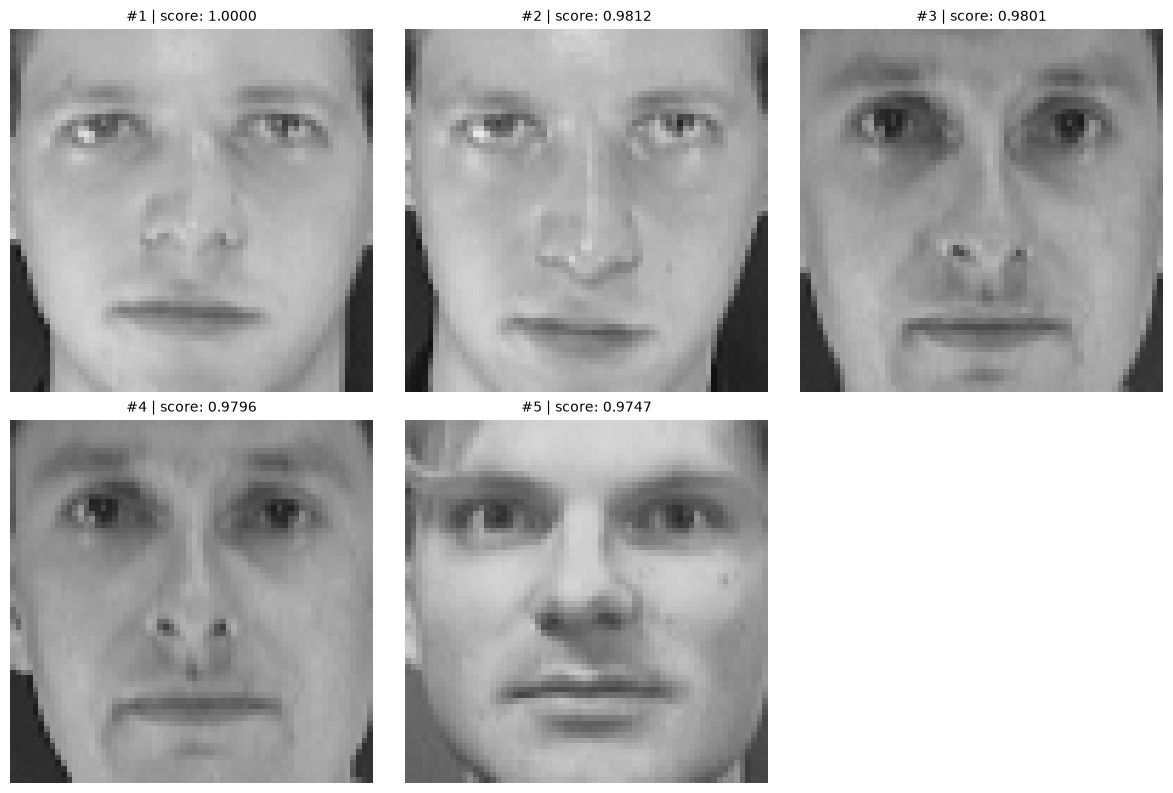

In [14]:
def search_by_image(image_path, top_k=5):
    query_emb = encoder.encode_images([image_path])[0][0]
    results = store.search(query_emb, top_k=top_k)
    print(f"Query image: {image_path}")
    for rank, hit in enumerate(results.points, 1):
        print(f'{rank}. {hit.payload["path"]} (score: {hit.score:.4f})')
    return results


query_image_path = image_paths[0]
img = Image.open(query_image_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.title("Query image")
plt.show()

results = search_by_image(query_image_path, top_k=5)
show_results(results, cols=3)
